<a href="https://colab.research.google.com/github/pprieri/ml/blob/main/NER_on_Annoted_Data_Corpus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

- This Notebook uses the 'Annotated Corpus for Named Entity Recognition' dataset.

- The Model is a Bidirectional LSTM with Space1D Dropout + Time Distributed Dense Layer

- It achieves 98% accuracy in classifying Tags

**Context**:
Annotated Corpus for Named Entity Recognition using GMB(Groningen Meaning Bank) corpus for entity classification with enhanced and popular features by Natural Language Processing applied to the data set.

**Content**:
This is the extract from GMB corpus which is tagged, annotated and built specifically to train the classifier to predict named entities such as name, location, etc.

Essential info about entities:

geo = Geographical Entity
org = Organization
per = Person
gpe = Geopolitical Entity
tim = Time indicator
art = Artifact
eve = Event
nat = Natural Phenomenon
Total Words Count = 1354149

Target Data Column: "tag"

More info here: https://www.kaggle.com/abhinavwalia95/entity-annotated-corpus

Import Modules

In [ ]:
# !pip install livelossplot

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
np.random.seed(0)
plt.style.use("ggplot")

import tensorflow as tf
print('Tensorflow version:', tf.__version__)
print('GPU detected:', tf.config.list_physical_devices('GPU'))

Tensorflow version: 2.6.0
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load and Explore the NER Dataset

*Essential info about tagged entities*:
- geo = Geographical Entity
- org = Organization
- per = Person
- gpe = Geopolitical Entity
- tim = Time indicator
- art = Artifact
- eve = Event
- nat = Natural Phenomenon

In [2]:
from google.colab import drive
drive.mount('/content/drive')
path = 'content/drive/MyDrive/Colab Notebooks/nlp/Data/NER Dataset'
%cd ..
%cd path

Mounted at /content/drive
/
/content/drive/MyDrive/Colab Notebooks/nlp/Data/NER Dataset


In [31]:
data = pd.read_csv("ner_dataset.csv", encoding="latin1")
data = data.fillna(method="ffill")
data.head(20)

,Sentence #,Word,POS,Tag
0,Sentence: 1,Thousands,NNS,O
1,Sentence: 1,of,IN,O
2,Sentence: 1,demonstrators,NNS,O
3,Sentence: 1,have,VBP,O
4,Sentence: 1,marched,VBN,O
5,Sentence: 1,through,IN,O
6,Sentence: 1,London,NNP,B-geo
7,Sentence: 1,to,TO,O
8,Sentence: 1,protest,VB,O
9,Sentence: 1,the,DT,O


In [32]:
print("Unique words in corpus:", data['Word'].nunique())
print("Unique tags in corpus:", data['Tag'].nunique())

Unique words in corpus: 35178
Unique tags in corpus: 17


In [33]:
words = list(set(data["Word"].values))
words.append("ENDPAD")
num_words = len(words)

In [34]:
tags = list(set(data["Tag"].values))
num_tags = len(tags)

# Retrieve Sentences and Corresponsing Tags

In [7]:
class SentenceGetter(object):
    def __init__(self, data):
        self.n_sent = 1
        self.data = data
        self.empty = False
        agg_func = lambda s: [(w, p, t) for w, p, t in zip(s["Word"].values.tolist(),
                                                           s["POS"].values.tolist(),
                                                           s["Tag"].values.tolist())]
        self.grouped = self.data.groupby("Sentence #").apply(agg_func)
        self.sentences = [s for s in self.grouped]
    
    def get_next(self):
        try:
            s = self.grouped["Sentence: {}".format(self.n_sent)]
            self.n_sent += 1
            return s
        except:
            return None

In [8]:
getter = SentenceGetter(data)
sentences = getter.sentences

In [9]:
sentences[0]

[('Thousands', 'NNS', 'O'),
 ('of', 'IN', 'O'),
 ('demonstrators', 'NNS', 'O'),
 ('have', 'VBP', 'O'),
 ('marched', 'VBN', 'O'),
 ('through', 'IN', 'O'),
 ('London', 'NNP', 'B-geo'),
 ('to', 'TO', 'O'),
 ('protest', 'VB', 'O'),
 ('the', 'DT', 'O'),
 ('war', 'NN', 'O'),
 ('in', 'IN', 'O'),
 ('Iraq', 'NNP', 'B-geo'),
 ('and', 'CC', 'O'),
 ('demand', 'VB', 'O'),
 ('the', 'DT', 'O'),
 ('withdrawal', 'NN', 'O'),
 ('of', 'IN', 'O'),
 ('British', 'JJ', 'B-gpe'),
 ('troops', 'NNS', 'O'),
 ('from', 'IN', 'O'),
 ('that', 'DT', 'O'),
 ('country', 'NN', 'O'),
 ('.', '.', 'O')]

# Define Mappings between Sentences and Tags

In [35]:
word2idx = {w: i + 1 for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}

In [29]:
#First 5 words
list(word2idx.keys())[:5]

['retirees', 'Qinghai', 'monasteries', 'suburban', 'Sebastian']

In [28]:
#Last 5 words
list(word2idx.keys())[-5:]

['unsuccessful', 'ex-Beatle', 'refueling', 'Engineer', 'ENDPAD']

# Padding Input Sentences and Creating Train/Test Splits

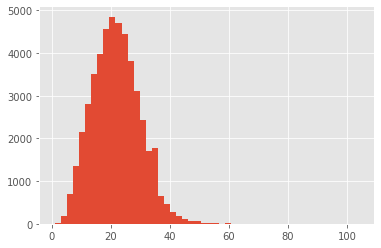

In [12]:
#In order to define length of padding, let's get the distribution of the length of sentences
plt.hist([len(s) for s in sentences], bins=50)
plt.show()

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50

X = [[word2idx[w[0]] for w in s] for s in sentences]
X = pad_sequences(maxlen=max_len, sequences=X, padding="post", value=num_words-1)

y = [[tag2idx[w[2]] for w in s] for s in sentences]
y = pad_sequences(maxlen=max_len, sequences=y, padding="post", value=tag2idx["O"])

In [43]:
print('max length of padding is: {} \n'.format(max_len))
print('vocab size = number of words = {} \n'.format(num_words)) 

print('Shape of X: {} \n'.format(X.shape))
print('Shape of y: {} \n'.format(y.shape))

max length of padding is: 50 

vocab size = number of words = 35179 

Shape of X: (47959, 50) 

Shape of y: (47959, 50) 



In [14]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Build and Compile a Bidirectional LSTM Model

In [15]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Embedding, Dense
from tensorflow.keras.layers import TimeDistributed, SpatialDropout1D, Bidirectional

In [16]:
input_word = Input(shape=(max_len,))
model = Embedding(input_dim=num_words, output_dim=50, input_length=max_len)(input_word)
model = SpatialDropout1D(0.1)(model) #drops out filter maps across all the channels
model = Bidirectional(LSTM(units=100, return_sequences=True, recurrent_dropout=0.1))(model)
out = TimeDistributed(Dense(num_tags, activation="softmax"))(model)
model = Model(input_word, out)
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 50)]              0         
_________________________________________________________________
embedding (Embedding)        (None, 50, 50)            1758950   
_________________________________________________________________
spatial_dropout1d (SpatialDr (None, 50, 50)            0         
_________________________________________________________________
bidirectional (Bidirectional (None, 50, 200)           120800    
_________________________________________________________________
time_distributed (TimeDistri (None, 50, 17)            3417      
Total params: 1,883,167
Trainable params: 1,883,167
Non-trainable params: 0
_________________________________________________________________


In [17]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train the Model

In [21]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from livelossplot.tf_keras import PlotLossesCallback

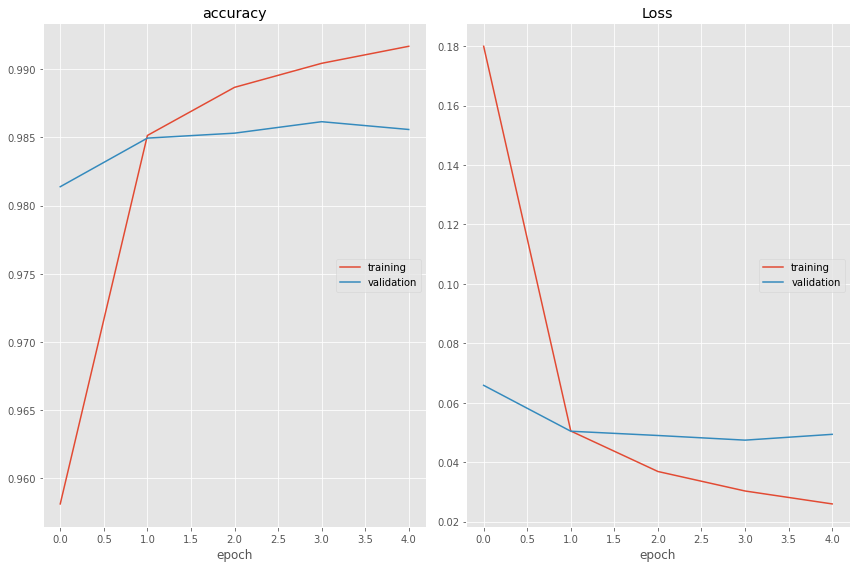

accuracy
	training         	 (min:    0.958, max:    0.992, cur:    0.992)
	validation       	 (min:    0.981, max:    0.986, cur:    0.986)
Loss
	training         	 (min:    0.026, max:    0.180, cur:    0.026)
	validation       	 (min:    0.047, max:    0.066, cur:    0.049)

Epoch 00005: val_loss did not improve from 0.04741
CPU times: user 1h 26min 31s, sys: 15min 49s, total: 1h 42min 21s
Wall time: 58min 42s


In [22]:
%%time

chkpt = ModelCheckpoint("model_weights.h5", monitor='val_loss',verbose=1, save_best_only=True, save_weights_only=True, mode='min')

early_stopping = EarlyStopping(monitor='val_accuracy', min_delta=0, patience=1, verbose=0, mode='max', baseline=None, restore_best_weights=False)

callbacks = [PlotLossesCallback(), chkpt, early_stopping]

history = model.fit(
    x=x_train,
    y=y_train,
    validation_data=(x_test,y_test),
    batch_size=32, 
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

# Evaluate Named Entity Recognition Model

In [23]:
model.evaluate(x_test, y_test)

300/300 [==============================] - 11s 38ms/step - loss: 0.0494 - accuracy: 0.9856


[0.04936277121305466, 0.985573410987854]

In [52]:
import operator
sorted(list(word2idx.items()),reverse=True,key=operator.itemgetter(1))[:5]

[('ENDPAD', 35179),
 ('Engineer', 35178),
 ('refueling', 35177),
 ('ex-Beatle', 35176),
 ('unsuccessful', 35175)]

In [24]:
i = np.random.randint(0, x_test.shape[0]) #659
p = model.predict(np.array([x_test[i]]))
p = np.argmax(p, axis=-1)
y_true = y_test[i]
print("{:15}{:5}\t {}\n".format("Word", "True", "Pred"))
print("-" *30)
for w, true, pred in zip(x_test[i], y_true, p[0]):
    print("{:15}{}\t{}".format(words[w-1], tags[true], tags[pred]))

Word           True 	 Pred

------------------------------
The            O	O
United         B-org	B-org
Nations        I-org	I-org
has            O	O
been           O	O
under          O	O
fire           O	O
for            O	O
failing        O	O
to             O	O
stop           O	O
ongoing        O	O
ethnic         O	O
violence       O	O
in             O	O
Ituri          B-geo	B-geo
.              O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engineer       O	O
Engin